### 实验课要求：
下面是一个使用Pytorch搭建CNN网络进行MNIST图像分类的程序  
程序有些错误，请改正

## 读取数据

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import gzip
import os
import struct
import numpy as np
from torch.utils.tensorboard import SummaryWriter

summary_writer = SummaryWriter('runs/mnist_cnn')

def load_mnist(path, kind='train'):
    """加载MNIST数据集"""
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')

    with gzip.open(labels_path, 'rb') as lbpath:
        struct.unpack('>II', lbpath.read(8))
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8)

    with gzip.open(images_path, 'rb') as imgpath:
        struct.unpack('>IIII', imgpath.read(16))
        images = np.frombuffer(imgpath.read(), dtype=np.uint8).reshape(len(labels),1,28,28)

    return images, labels



# 数据集划分
def data_split(images, labels, ratio):
    
    total_len = images.shape[0]
    offset = int(total_len * ratio)

    val_img = images[:offset][:]
    val_lb = labels[:offset]

    train_img = images[offset:][:]
    train_lb = labels[offset:]

    return train_img, train_lb, val_img, val_lb    

# 读取训练集和测试集数据
[images, labels] = load_mnist('../MNIST', kind='train')
[test_img, test_lb] = load_mnist('../MNIST',kind='test')
train_img, train_lb, val_img, val_lb = data_split(images, labels, 1/6)

# 为了加快调试速度，从训练集选择2000个样本。
random_numbers = np.random.randint(50000, size=(8000, ))
train_img=train_img[random_numbers]
train_lb= train_lb [random_numbers]

# 将所有数据归一化到0-1之间
train_img =train_img/255.
val_img   =val_img/255.
test_img  =test_img/255.

# 对标签进行热编码
one_hot_train_lb = np.eye(10)[train_lb]
one_hot_val_lb = np.eye(10)[val_lb]
one_hot_test_lb= np.eye(10)[test_lb]

# 打印查看数据集格式
print('训练集图像格式为:', train_img.shape, '训练集标签格式为:', train_lb.shape,'热编码训练集标签格式为:', one_hot_train_lb.shape)
print('验证集图像格式为:', val_img.shape, '验证集标签格式为:', val_lb.shape,'热编码验证集标签格式为:', one_hot_val_lb.shape)
print('测试集图像格式为:', test_img.shape, '测试集标签格式为:', test_lb.shape,'热编码测试集标签格式为:', one_hot_test_lb.shape)

训练集图像格式为: (8000, 1, 28, 28) 训练集标签格式为: (8000,) 热编码训练集标签格式为: (8000, 10)
验证集图像格式为: (10000, 1, 28, 28) 验证集标签格式为: (10000,) 热编码验证集标签格式为: (10000, 10)
测试集图像格式为: (10000, 1, 28, 28) 测试集标签格式为: (10000,) 热编码测试集标签格式为: (10000, 10)


## 数据增强处理

In [ ]:

from torchvision.transforms import v2
from torchvision.io import read_image
train_img1=torch.tensor(train_img, dtype=torch.float32)
test_img1=torch.tensor(test_img, dtype=torch.float32)

transforms = v2.Compose([
    #v2.RandomHorizontalFlip(p=0.5),
    #v2.Normalize(mean=[0.485], std=[0.229]),
    v2.RandomRotation(degrees=(-15, 15))
    ])

augmented_sample = transforms(train_img1)
train_img = torch.cat((augmented_sample,train_img1))
one_hot_train_lb  = np.concatenate((one_hot_train_lb,one_hot_train_lb),axis=0)

程序改错，构建并训练一个卷积网络

In [70]:
#网络包含3个卷积层、2个线性层、3个BN层
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()  # 修改卷积参数
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=1)
        self.w1 =nn.Linear(784,100) # 784 = 16*7*7
        self.w2 =nn.Linear(100,10)
        self.BN1=nn.BatchNorm2d(16)
        self.BN2=nn.BatchNorm2d(32)
        self.BN3=nn.BatchNorm2d(16)
        self.relu=nn.ReLU()
        self.dropout=nn.Dropout(p=0.5) # 提升大


    def forward(self, x):
        x = self.conv1 (x)
        x = self.BN1(x)
        x = self.relu(x)

        x = self.conv2 (x)
        x = self.BN2(x)
        x = self.relu(x)

        x = self.conv3 (x)
        x = self.BN3(x)
        x = self.relu(x)

        x = x.view(x.size(0), -1)
        x = self.w1 (x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.w2 (x)
        x = self.relu(x)        
        return x

model = NeuralNetwork()

# Initialize the loss function
loss_fn = nn.CrossEntropyLoss()

learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

batch_size = 200
epochs = 15
batch_num=int(train_img.shape[0]/batch_size)
size = len(train_img)

loss_his = []
acc_his = []
val_loss_his = []
val_acc_his = []

model.train()
for t in range(epochs):
    
    correct=0.
    train_mean_loss=0.

    for batch in range(batch_num):
        X=train_img[batch*batch_size:(batch+1)*batch_size,]
        y=one_hot_train_lb[batch*batch_size:(batch+1)*batch_size,:]

        X=torch.tensor(X, dtype=torch.float32)
        y=torch.tensor(y, dtype=torch.float32)
        
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        correct += (pred.argmax(1) == y.argmax(1)).type(torch.float).mean().item()
        train_mean_loss+= loss.item()

    train_mean_loss /= batch_num
    correct /= batch_num

    loss_his.append(train_mean_loss)
    acc_his.append(correct)
    summary_writer.add_scalar('Loss/train', train_mean_loss, t) 
    summary_writer.add_scalar('Accuracy/train', correct, t)

    model.eval()
    val_correct = 0.
    val_loss_sum = 0.
    with torch.no_grad():
        X_val = torch.tensor(val_img, dtype=torch.float32)
        y_val = torch.tensor(one_hot_val_lb, dtype=torch.float32)
        pred_val = model(X_val)
        val_loss = loss_fn(pred_val, y_val)
        val_acc = (pred_val.argmax(1) == y_val.argmax(1)).type(torch.float).mean().item()
    
    val_loss_his.append(val_loss.item())
    val_acc_his.append(val_acc)
    summary_writer.add_scalar('Loss/val', val_loss.item(), t)
    summary_writer.add_scalar('Accuracy/val', val_acc, t)
    model.train()

    print(f" Epoch:{t+1}, loss: {train_mean_loss:>8f}, Accuracy: {(100*correct):>0.1f}%, Val Loss: {val_loss.item():>8f}, Val Accuracy: {(100*val_acc):>0.1f}%")

summary_writer.close()

C:\Users\15548\AppData\Local\Temp\ipykernel_52532\378305503.py:67: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X=torch.tensor(X, dtype=torch.float32)


 Epoch:1, loss: 2.152930, Accuracy: 28.1%, Val Loss: 1.798366, Val Accuracy: 56.8%
 Epoch:2, loss: 1.483781, Accuracy: 61.9%, Val Loss: 0.966441, Val Accuracy: 83.0%
 Epoch:3, loss: 0.896169, Accuracy: 77.8%, Val Loss: 0.572198, Val Accuracy: 89.5%
 Epoch:4, loss: 0.610115, Accuracy: 84.3%, Val Loss: 0.407484, Val Accuracy: 91.6%
 Epoch:5, loss: 0.478321, Accuracy: 87.3%, Val Loss: 0.328308, Val Accuracy: 92.6%
 Epoch:6, loss: 0.396329, Accuracy: 89.3%, Val Loss: 0.279207, Val Accuracy: 93.1%
 Epoch:7, loss: 0.348197, Accuracy: 90.5%, Val Loss: 0.249536, Val Accuracy: 93.5%
 Epoch:8, loss: 0.308238, Accuracy: 91.6%, Val Loss: 0.228559, Val Accuracy: 94.0%
 Epoch:9, loss: 0.277944, Accuracy: 92.4%, Val Loss: 0.211416, Val Accuracy: 94.4%
 Epoch:10, loss: 0.256709, Accuracy: 93.1%, Val Loss: 0.196986, Val Accuracy: 94.8%
 Epoch:11, loss: 0.238153, Accuracy: 93.3%, Val Loss: 0.187611, Val Accuracy: 94.8%
 Epoch:12, loss: 0.221675, Accuracy: 93.9%, Val Loss: 0.176369, Val Accuracy: 95.1%
 

## 测试集

In [71]:
model.eval()
test_loss, correct = 0, 0

with torch.no_grad():
        X=torch.tensor(test_img, dtype=torch.float32) # 删除.view
        y=torch.tensor(one_hot_test_lb, dtype=torch.float32)
        pred = model(X)
        test_loss = np.mean(loss_fn(pred, y).item())
        correct = (pred.argmax(1) == y.argmax(1)).type(torch.float).mean().item()
        wrong_preds = (pred.argmax(1) != y.argmax(1))
        wrong_images = test_img[wrong_preds]
        wrong_preds = pred.argmax(1)[wrong_preds].numpy()
        wrong_trues = y.argmax(1)[wrong_preds].numpy()

print(f"Test Accuracy: {(100*correct):>0.1f}%, Test Avg loss: {test_loss:>8f} \n")


Test Accuracy: 96.1%, Test Avg loss: 0.135736 



## 结果处理与分析

### 绘制损失和精度曲线

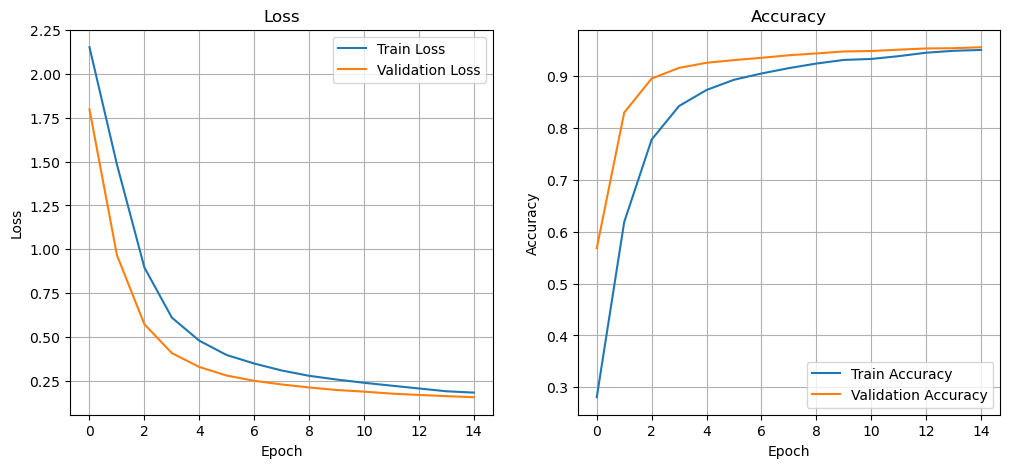

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_his, label='Train Loss')
plt.plot(val_loss_his, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(acc_his, label='Train Accuracy')
plt.plot(val_acc_his, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()


### 结果分析

1. **网络结构**  
   - 整个模型用了三层卷积、两层全连接和三层批归一化  
   - 第一层卷积：输入单通道灰度图，输出16个通道，卷积核3×3，步长1，边缘补1，保证图像尺寸不变  
   - 第二层卷积：输入16通道，输出32通道，同样用3×3卷积核，但步长改为2，补1，特征图尺寸减半  
   - 第三层卷积：输入32通道，输出16通道，步长仍为2，补1，尺寸再减半  
   - 全连接部分：先把特征图拉平（16×7×7=784维），接一个100个神经元的隐藏层，最后输出10类  
   - 每个卷积层后都加了批归一化和ReLU激活函数，全连接中间还加了0.5的Dropout来防止过拟合  

1. **调参经验**  
   - 训练集大小的影响：训练集越大，每轮耗时越长，但损失下降和精度上升都更快。为了控制训练时间，可以适当减少训练轮数。  
   - 小训练集（≤3000张）：需要更多轮数才能达到90%以上的精度，而且测试集精度跟训练集差不多，有时还略低一点。  
   - 大训练集（≥5000张）：精度上升明显更快，并且测试集精度总是高于训练集精度，泛化更好。  
   - 学习率：太小（<0.0001）时训练很慢，容易陷入局部最优；设为0.01时效率高，损失也不会爆炸。  

2. **数据增强**  
   - 使用了随机旋转（±15°）做数据增强，这样即使训练集不大，也能在测试集上取得不错的精度，明显减少了欠拟合现象。

### 问题分析

1. **数据增强的旋转角度问题**  
   - 原代码里数据增强用了0到180度的旋转，这会导致一些数字混淆，比如6和9、2和5容易互相认错  

2. **重复归一化的问题**  
   - 数据增强的预处理里包含了归一化操作，但前面读取数据时已经对图像做过一次除以255的归一化。两次归一化会出问题

## 评分标准：
#代码尽量简洁高效，不包含实验题目无关的函数、代码
#不用Pytorch库  
#按照题目大纲编写程序   
#课上能够完成   
#实验结果完整、格式规范   
#图文并茂、实验结果分析有自己的想法   